In [16]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

NR = 105
NZ = 105
NT = 10
Rf = np.zeros(NR)
Zf = np.zeros(NZ)

a = 0
b = 100
r = 1.01

N = 100
for i in range(N + 1):
    fraction = np.exp((i - N) * np.log(r)) * (1 - np.exp(-i * np.log(r))) / (1 - np.exp(-N * np.log(r)))
    Rf[i + 2] = a + (b - a ) * fraction
    Zf[i + 2] = a + (b - a ) * fraction

Rf[0] = -Rf[4]
Rf[1] = -Rf[3]
Rf[-1] = 2 * Rf[-3] - Rf[-5]
Rf[-2] = 2 * Rf[-3] - Rf[-4]
Zf[0] = -Zf[4]
Zf[1] = -Zf[3]
Zf[-1] = 2 * Zf[-3] - Zf[-5]
Zf[-2] = 2 * Zf[-3] - Zf[-4]
Rc = (Rf[1:] + Rf[:-1]) /2
Zc = (Zf[1:] + Zf[:-1]) /2


In [17]:
dV = Rc[:, None] * np.diff(Rf)[:,None] * np.diff(Zf)[None,:]
t = np.arange(10)*50

def numerical_diffusion(ndis):
    N_tot = np.sum(ndis_C * dV[None,:], axis = (1,2))
    mc_R = np.sum(ndis_C * Rc[None, :, None] * dV[None,:], axis = (1,2)) / N_tot
    mc_Z = np.sum(ndis_C * Zc[None, None, :] * dV[None,:], axis = (1,2)) / N_tot
    
    sigma_R = np.sum((Rc[None,:,None] - mc_R[:,None,None])**2 * ndis_C * dV[None,:], axis = (1,2)) / N_tot 
    sigma_Z = np.sum((Zc[None,None,:] - mc_Z[:,None,None])**2 * ndis_C * dV[None,:], axis = (1,2)) / N_tot 
    cov = np.sum((Rc[None,:,None]-mc_R[:,None,None])*(Zc[None,None,:]-mc_Z[:,None,None])*ndis_C*dV[None,:,:],axis=(1,2))/N_tot
    return N_tot, sigma_R, sigma_Z, cov

(0.0001, 10.0)

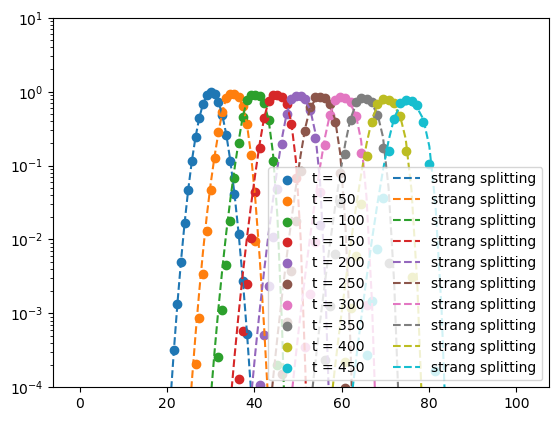

In [30]:
ndis_C = np.fromfile("ndis_C_dt1_t500_TVD_gg.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
ndis_C_ss = np.fromfile("ndis_C_dt1_t500_TVD_strang_split_gg.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)
ndis_C_PLM = np.fromfile("ndis_C_dt1_t500_PLM_gg.bin",dtype = np.float64).reshape(NT, NR - 1, NZ - 1)



for i in range(NT):
    plt.scatter(Zc, ndis_C_PLM[i, 43], label = f"t = {i*50}")
for i in range(NT):
    plt.plot(Zc, ndis_C_ss[i, 43], label = f"strang splitting", linestyle="--")
plt.yscale("log")
plt.legend(ncol=2)
plt.ylim(1e-4,1e1)

Text(0.5, 1.0, 'Total number of particles VS time')

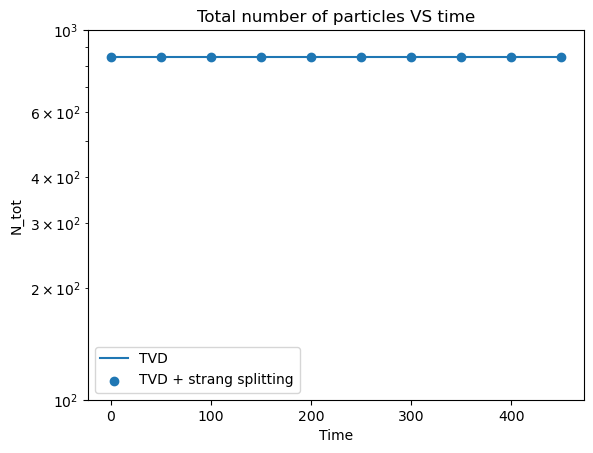

In [32]:
nd_tvd = numerical_diffusion(ndis_C)
nd_tvd_ss = numerical_diffusion(ndis_C_ss)
nd_PLM = numerical_diffusion(ndis_C_PLM)


plt.plot(t, nd_PLM[0], label = "TVD")
plt.scatter(t, nd_tvd_ss[0], label = "TVD + strang splitting")

# plt.xscale("log")
plt.yscale("log")
plt.ylim(1e2,1e3)
plt.legend()
plt.ylabel("N_tot")
plt.xlabel("Time")
plt.title("Total number of particles VS time")

Text(0.5, 1.0, 'Distribution extension VS time')

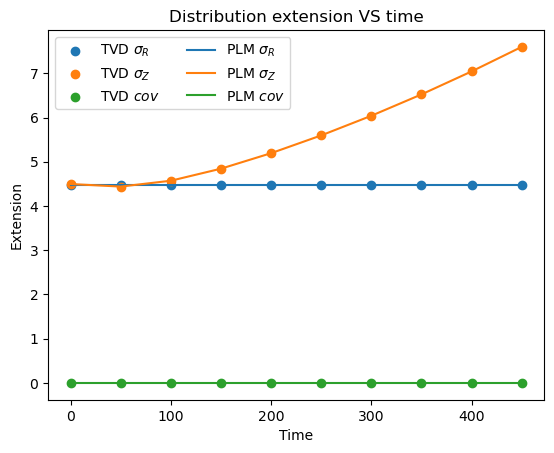

In [34]:


plt.scatter(t, nd_tvd[1], label = f"TVD $\sigma_R$")
plt.scatter(t, nd_tvd[2], label = f"TVD $\sigma_Z$")
plt.scatter(t, nd_tvd[3], label = f"TVD $cov$")

# plt.plot(t, nd_tvd_ss[1], label = f"TVD+strang split")
# plt.plot(t, nd_tvd_ss[2], label = f"TVD+strang split ")
# plt.plot(t, nd_tvd_ss[3], label = f"TVD+strang split ")

plt.plot(t, nd_PLM[1], label = f"PLM $\sigma_R$")
plt.plot(t, nd_PLM[2], label = f"PLM $\sigma_Z$")
plt.plot(t, nd_PLM[3], label = f"PLM $cov$")

# plt.xscale("log")
# plt.yscale("log")
plt.legend(ncol=2)
plt.ylabel("Extension")
plt.xlabel("Time")
plt.title("Distribution extension VS time")